## Train A Test A

Category distribution:
Device Type
Coordinator    8650
Socket         8300
Bulb           3839
Motion          206
Door             69
Button           17
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.94      0.94      0.94       724
      Button       1.00      0.33      0.50         3
 Coordinator       0.97      0.97      0.97      1674
        Door       1.00      0.89      0.94        18
      Motion       0.82      0.73      0.77        44
      Socket       0.97      0.98      0.98      1754

    accuracy                           0.96      4217
   macro avg       0.95      0.81      0.85      4217
weighted avg       0.96      0.96      0.96      4217

Weighted F1-Score: 0.9644


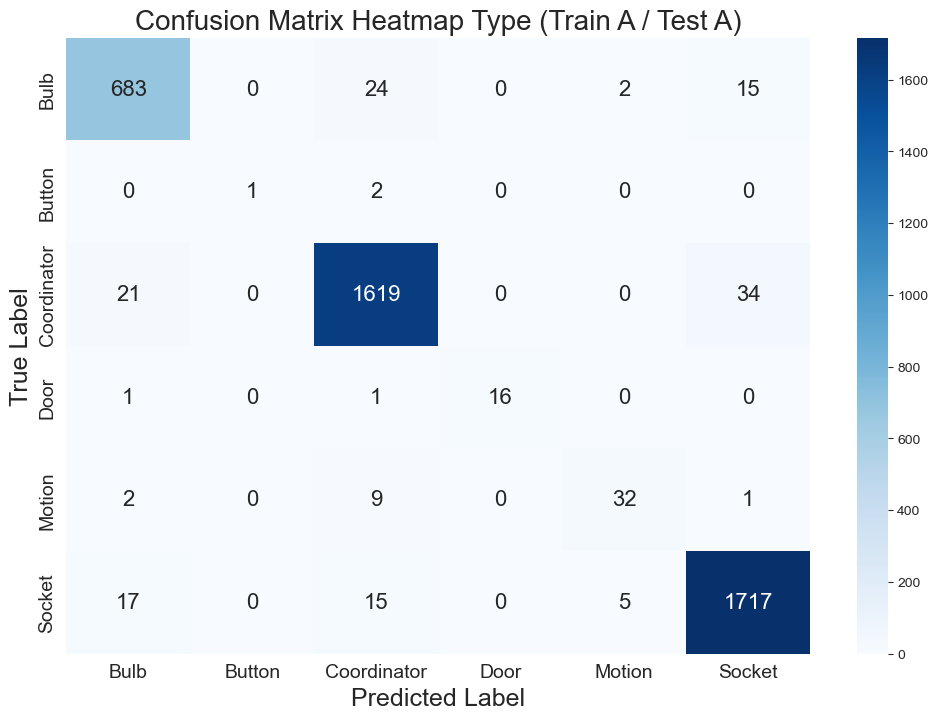

In [12]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)


X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train A / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


Category distribution:
2     8650
13    2949
12    2606
11    2385
3     1165
10     742
6      726
7      669
8      537
5      221
9      194
4      139
1       50
0       17
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      0.67      0.80         3
        Aqara Door 1       0.80      1.00      0.89         8
         Coordinator       0.97      0.97      0.97      1747
       Ledvance Bulb       0.92      0.92      0.92       229
Ledvance Smart+ Plug       0.93      0.80      0.86        35
    Ledvance Z3 Plug       0.79      0.76      0.78        41
           Moes Bulb       0.94      0.89      0.92       132
      Philips Lamp 1       0.81      0.72      0.77       122
      Philips Lamp 2       0.83      0.89      0.86        97
      Philips Lamp 3       0.82      0.79      0.80        42
      Philips Motion       0.83      0.82      0.83       145
        Power Plug 1       0.95      0.93      0.94 

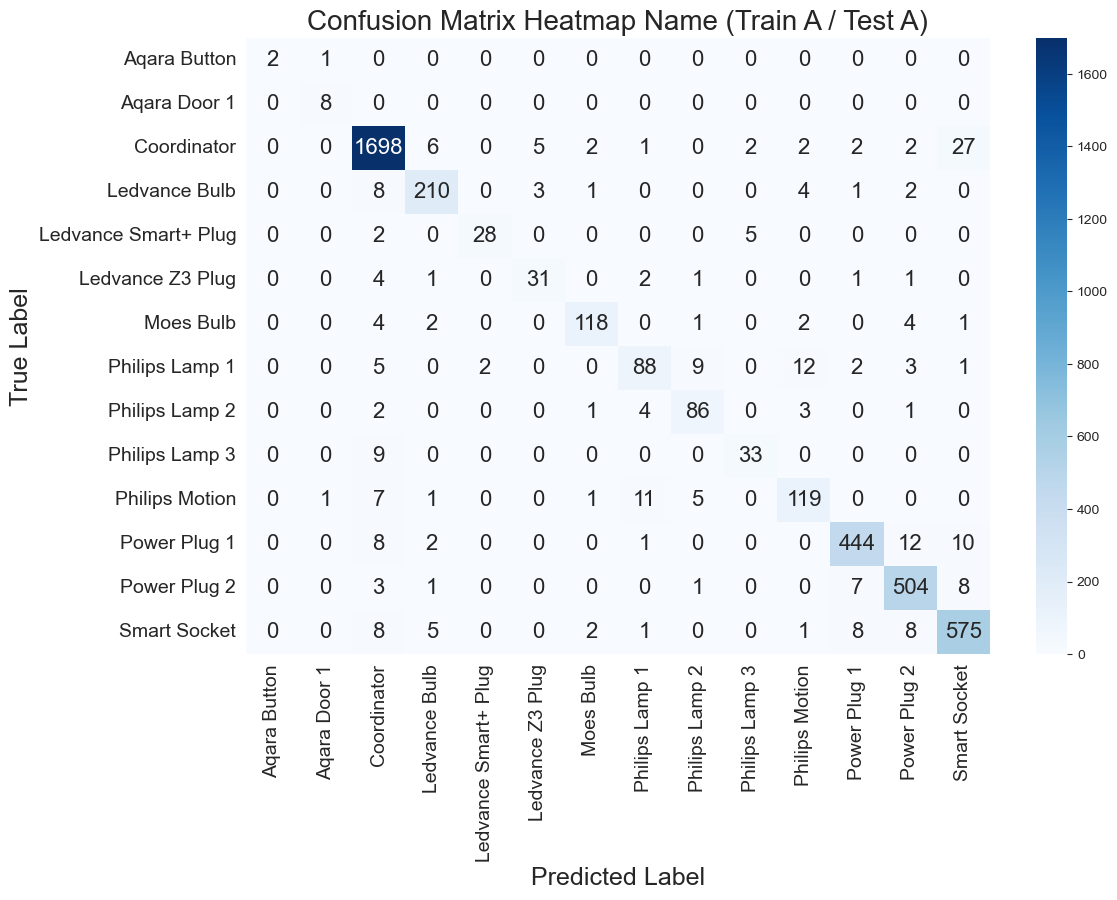

In [13]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Train B Test B

Category distribution:
Device Type
Socket         14573
Coordinator    11594
Bulb            4228
Motion           554
Door              45
Button            35
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.95      0.94      0.95       862
      Button       0.90      1.00      0.95         9
 Coordinator       0.98      0.97      0.97      2309
        Door       0.83      1.00      0.91         5
      Motion       0.96      0.99      0.97       117
      Socket       0.98      0.99      0.98      2904

    accuracy                           0.97      6206
   macro avg       0.93      0.98      0.96      6206
weighted avg       0.97      0.97      0.97      6206

Weighted F1-Score: 0.9745


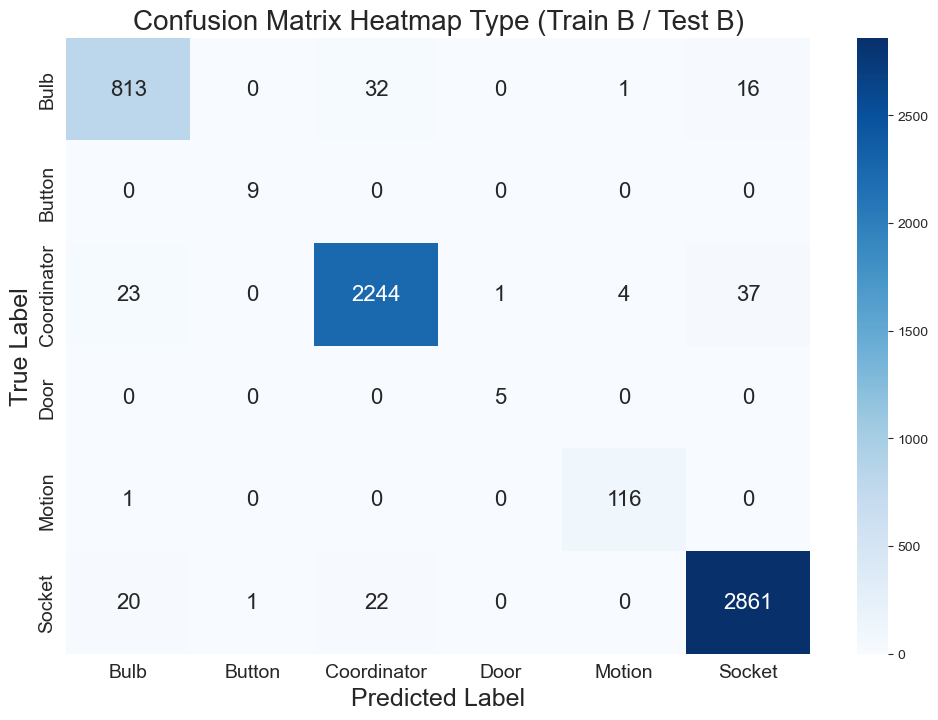

In [14]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)


X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train B / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


Category distribution:
2     11594
13     5506
11     4682
12     3994
3      1312
7      1184
9       942
10      511
6       405
8       385
5       321
4        70
0        35
14       33
1        29
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.89      1.00      0.94         8
        Aqara Door 2       1.00      0.57      0.73         7
         Coordinator       0.96      0.98      0.97      2329
       Ledvance Bulb       0.95      0.87      0.91       282
Ledvance Smart+ Plug       0.90      0.69      0.78        13
    Ledvance Z3 Plug       0.92      0.84      0.88        58
           Moes Bulb       0.93      0.89      0.91        80
      Philips Lamp 1       0.90      0.89      0.90       242
      Philips Lamp 2       0.93      0.79      0.85        81
      Philips Lamp 3       0.89      0.85      0.87       169
      Philips Motion       0.96      0.98      0.97       123
        Power Plug 1      

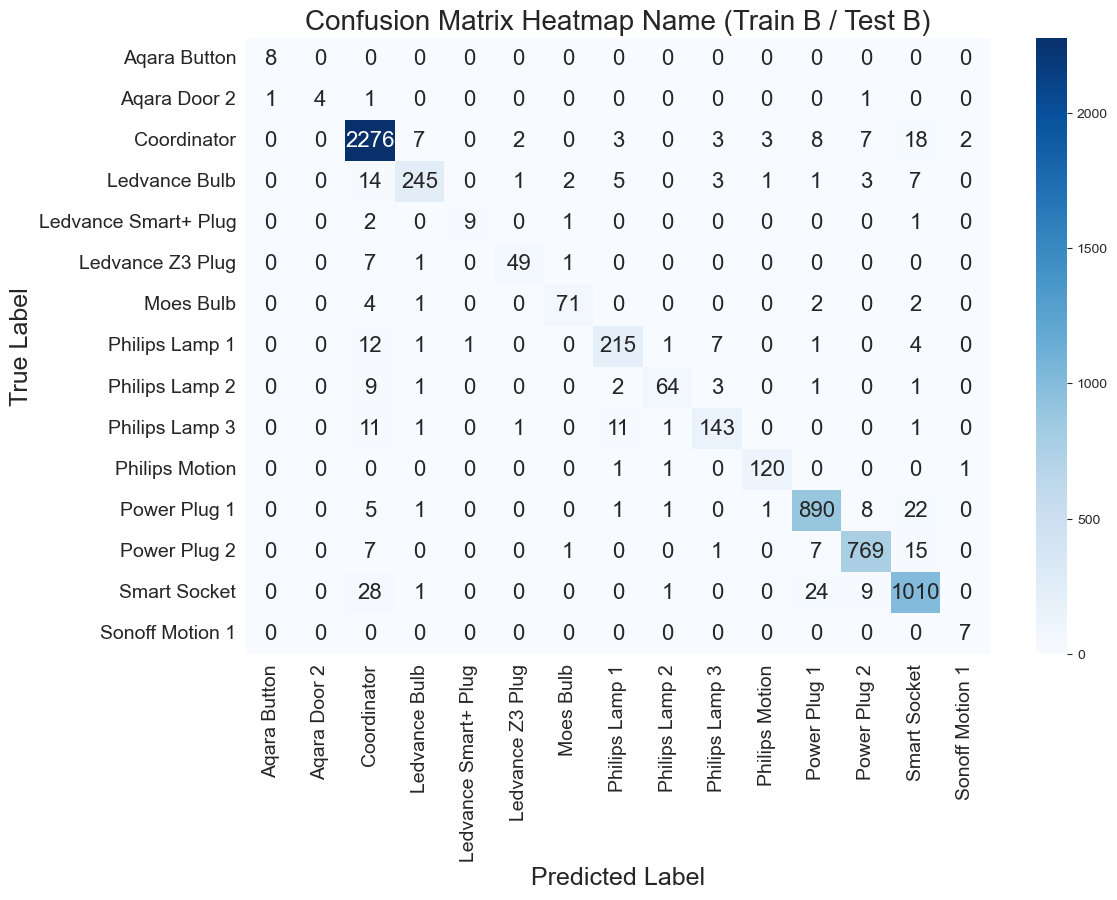

In [15]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train B / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Train A Test B

Category distribution:
2    8650
5    8300
0    3839
4     206
3      69
1      17
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.65      0.82      0.73      4228
      Button       0.71      0.63      0.67        35
 Coordinator       0.88      0.93      0.90     11594
        Door       0.57      0.64      0.60        45
      Motion       0.87      0.57      0.69       554
      Socket       0.93      0.83      0.88     14573

    accuracy                           0.86     31029
   macro avg       0.77      0.74      0.75     31029
weighted avg       0.87      0.86      0.86     31029

Weighed F1-Score: 0.8632


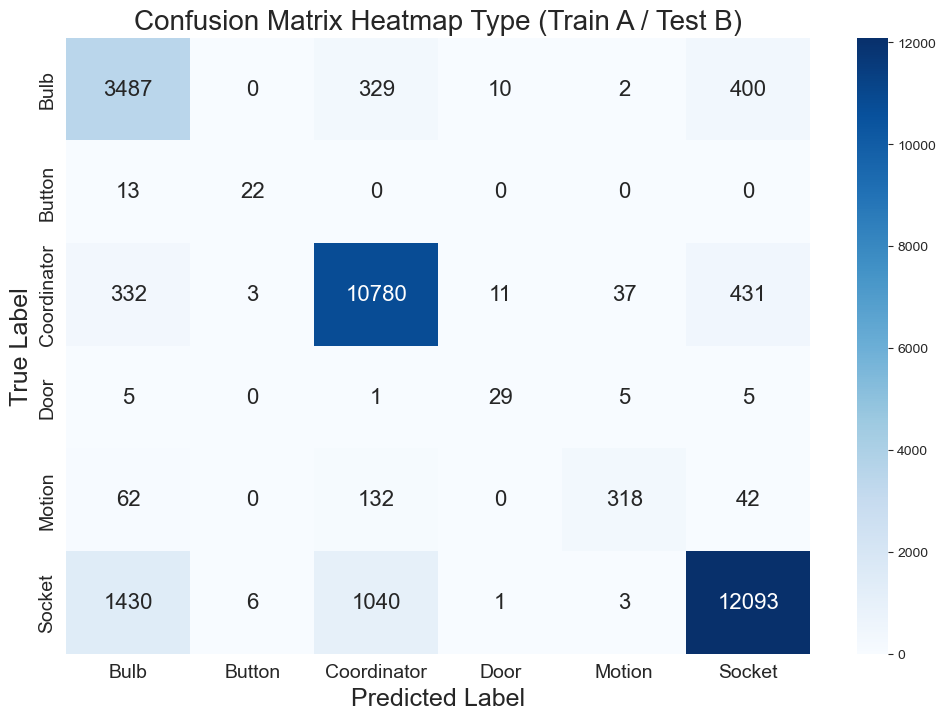

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data[feature_columns]
y_test = test_data["Device Type"]

y_test = test_data["Device Type"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighed F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
2     8650
13    2949
12    2606
11    2385
3     1165
10     742
6      726
7      669
8      537
5      221
9      194
4      139
1       50
0       17
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.70      0.60      0.65        35
        Aqara Door 1       0.00      0.00      0.00         0
         Coordinator       0.85      0.93      0.89     11594
       Ledvance Bulb       0.63      0.67      0.65      1312
Ledvance Smart+ Plug       0.30      0.19      0.23        70
    Ledvance Z3 Plug       0.05      0.04      0.05       321
           Moes Bulb       0.25      0.55      0.34       405
      Philips Lamp 1       0.37      0.23      0.29      1184
      Philips Lamp 2       0.06      0.14      0.08       385
      Philips Lamp 3       0.00      0.00      0.00       942
      Philips Motion       0.01      0.01      0.01       511
        Power Plug 1       0.44      0.33      0.38 

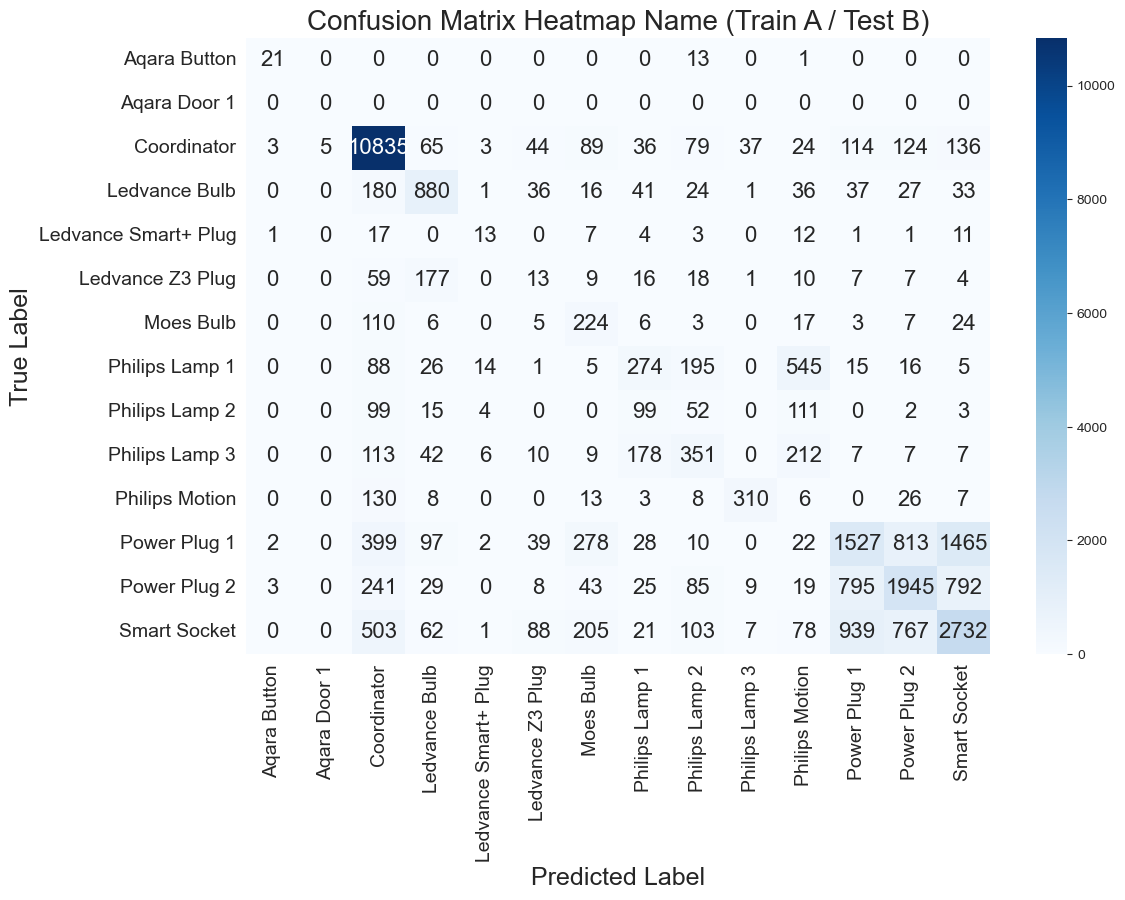

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)
train_data = filter_small_classes(train_data)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)
test_data = filter_small_classes(test_data)

X_test = test_data[feature_columns]
y_test = test_data["Device Name"]

y_test = test_data["Device Name"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Train B Test A

Category distribution:
5    14573
2    11594
0     4228
4      554
3       45
1       35
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.83      0.72      0.77      3839
      Button       0.55      0.35      0.43        17
 Coordinator       0.88      0.82      0.85      8650
        Door       0.89      0.46      0.61        69
      Motion       0.63      0.50      0.56       206
      Socket       0.80      0.91      0.85      8300

    accuracy                           0.83     21081
   macro avg       0.76      0.63      0.68     21081
weighted avg       0.84      0.83      0.83     21081

Weighed F1-Score: 0.8317


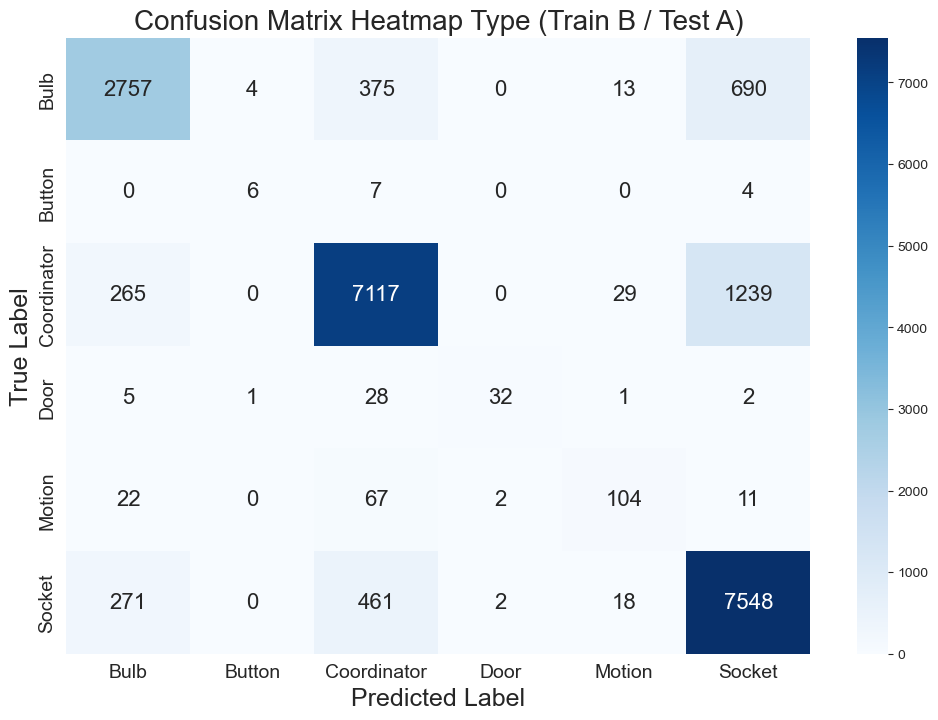

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

# 加载测试数据
test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data[feature_columns]
y_test = test_data["Device Type"]

y_test = test_data["Device Type"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighed F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train B / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
2     11594
13     5506
11     4682
12     3994
3      1312
7      1184
9       942
10      511
6       405
8       385
5       321
4        70
0        35
14       33
1        29
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.60      0.35      0.44        17
         Coordinator       0.87      0.84      0.85      8650
       Ledvance Bulb       0.69      0.67      0.68      1165
Ledvance Smart+ Plug       0.24      0.06      0.10       139
    Ledvance Z3 Plug       0.15      0.07      0.09       221
           Moes Bulb       0.69      0.19      0.29       726
      Philips Lamp 1       0.30      0.47      0.36       669
      Philips Lamp 2       0.19      0.09      0.12       537
      Philips Lamp 3       0.00      0.01      0.00       194
      Philips Motion       0.01      0.00      0.00       742
        Power Plug 1       0.35      0.37      0.36      2385
        Power Plug 2      

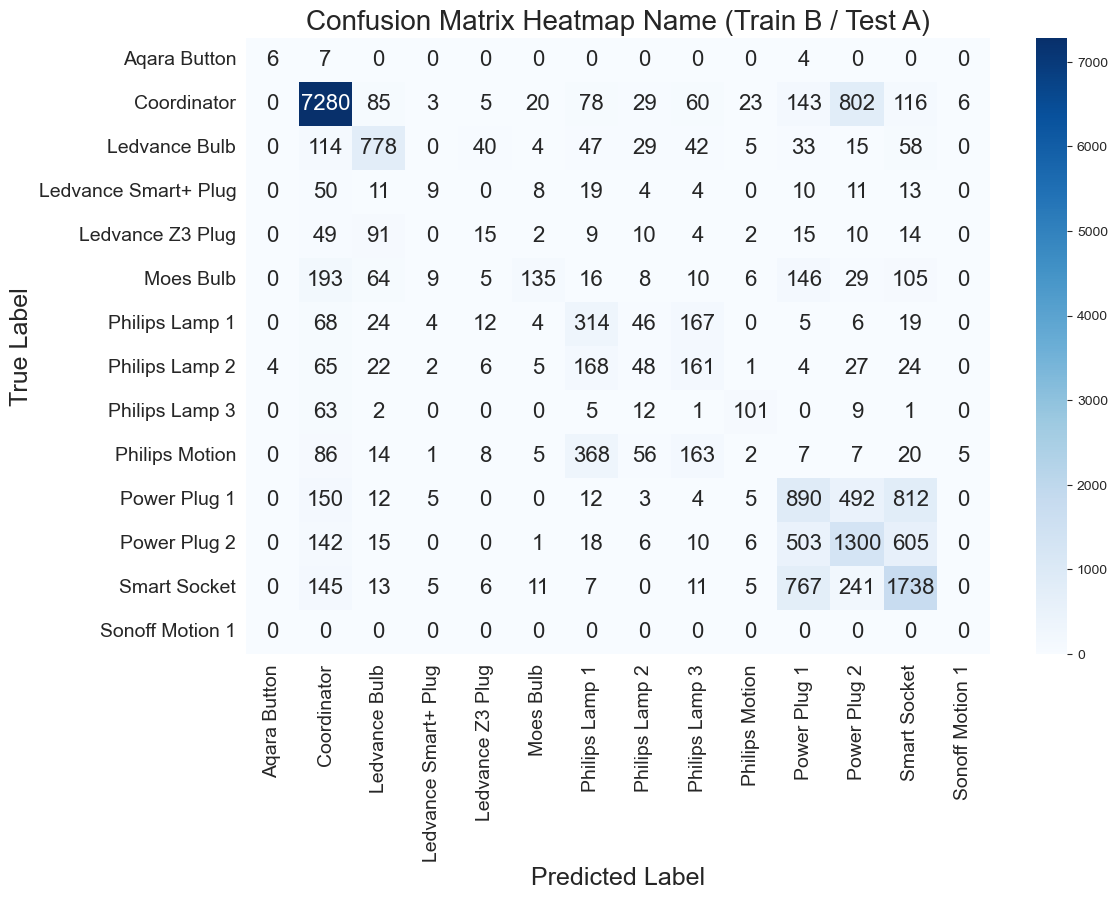

In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)
train_data = filter_small_classes(train_data)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)
test_data = filter_small_classes(test_data)

X_test = test_data[feature_columns]
y_test = test_data["Device Name"]

y_test = test_data["Device Name"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train B / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()